In [ ]:
RANDOM_STATE = 42

def set_seeds(seed: int = 42):
    import random
    import numpy as np

    random.seed(seed)
    np.random.seed(seed)

set_seeds(RANDOM_STATE)

In [ ]:
#  Load Dataset

import pandas as pd

DATA_PATH = "/content/Roofing_Data.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully
Shape: (2500, 6)


,roof_area_m2,roof_height_m,roof_type,roof_covering,labor_count,duration_days
0,275.1,1.25,Gable,Concrete Tiles,4,37
1,174.5,2.93,Flat,RC Slab,9,27
2,311.7,3.88,Lean-to,Asbestos Sheets,10,17
3,247.6,3.35,Gable,Clay Tiles,15,20
4,95.6,2.08,Gable,Clay Tiles,4,18


In [ ]:
print(df.dtypes )

roof_area_m2     float64
roof_height_m    float64
roof_type         object
roof_covering     object
labor_count        int64
duration_days      int64
dtype: object


In [ ]:
#  Detect Target Column

possible_targets = ["Duration_Days", "Duration_days", "duration_days", "duration"]
TARGET_COL = next((col for col in possible_targets if col in df.columns), None)

if TARGET_COL is None:
    raise ValueError(f"Target column not found. Checked: {possible_targets}\nAvailable columns: {df.columns.tolist()}")

print(" Target Column:", TARGET_COL)

 Target Column: duration_days


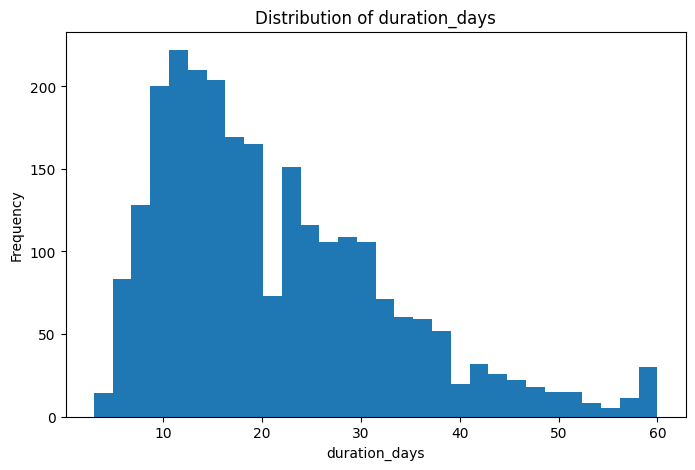

In [ ]:
#  Distribution of Target

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df[TARGET_COL], bins=30)
plt.title(f"Distribution of {TARGET_COL}")
plt.xlabel(TARGET_COL)
plt.ylabel("Frequency")
plt.show()

In [ ]:

#  Preprocessing Functions

def split_features_target(df, target_col):
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()
    return X, y

def build_preprocessor(X, scale_numeric=False):
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(steps=numeric_steps)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    return preprocessor

In [ ]:

# Define Features and Target

X, y = split_features_target(df, TARGET_COL)

print(" Feature columns:")
print(X.columns.tolist())

 Feature columns:
['roof_area_m2', 'roof_height_m', 'roof_type', 'roof_covering', 'labor_count']


In [ ]:

#  Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

Train = (len(X_train) / len(X)) * 100
Test = (len(X_test) / len(X)) * 100

print(f" Train Percentage: {Train:.0f}%")
print(f"Test Percentage: {Test:.0f}%")

 Train Percentage: 80%
Test Percentage: 20%


In [ ]:
# Model Training Functions

# Linear Regression

def train_linear_regression(X_train, y_train):
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LinearRegression

    preprocessor = build_preprocessor(X_train, scale_numeric=True)

    model = LinearRegression()

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    return pipeline

In [ ]:
# Random Forest Regressor

def train_random_forest(X_train, y_train, random_state=42):
    from sklearn.pipeline import Pipeline
    from sklearn.ensemble import RandomForestRegressor

    preprocessor = build_preprocessor(X_train, scale_numeric=False)

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        n_jobs=-1
    )

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    return pipeline

In [ ]:
# XGBoost Regressor

def train_xgboost(X_train, y_train, random_state=42):
    from sklearn.pipeline import Pipeline
    from xgboost import XGBRegressor

    preprocessor = build_preprocessor(X_train, scale_numeric=False)

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=random_state,
        n_jobs=-1
    )

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    return pipeline

In [ ]:
# Train All Models

lr_model = train_linear_regression(X_train, y_train)
rf_model = train_random_forest(X_train, y_train, random_state=RANDOM_STATE)
xgb_model = train_xgboost(X_train, y_train, random_state=RANDOM_STATE)

print(" Linear Regression trained")
print(" Random Forest trained")
print(" XGBoost trained")

 Linear Regression trained
 Random Forest trained
 XGBoost trained


In [ ]:
#  Evaluation Functions

import numpy as np

def regression_accuracy_with_tolerance(y_true, y_pred, tolerance=0.10):
    """
    Accuracy = % predictions within ±10% of actual value
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = np.where(y_true == 0, 1.0, y_true)
    relative_error = np.abs(y_pred - y_true) / np.abs(denominator)

    return float(np.mean(relative_error <= tolerance))

def evaluate_model(model_name, model, X_test, y_test):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    accuracy = regression_accuracy_with_tolerance(y_test, y_pred, tolerance=0.10)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Accuracy_±10%": accuracy
    }

In [ ]:

#  Evaluate All Models

import pandas as pd

results = []
results.append(evaluate_model("Linear Regression", lr_model, X_test, y_test))
results.append(evaluate_model("Random Forest", rf_model, X_test, y_test))
results.append(evaluate_model("XGBoost", xgb_model, X_test, y_test))

results_df = pd.DataFrame(results).sort_values(by="MAE", ascending=True)

display(results_df)

,Model,MAE,RMSE,R2,Accuracy_±10%
2,XGBoost,1.510153,2.093989,0.967208,0.72
1,Random Forest,1.651453,2.263451,0.961685,0.64
0,Linear Regression,3.632487,4.945729,0.817071,0.37


In [ ]:

#  Select Best Model

best_row = results_df.iloc[0]
best_model_name = best_row["Model"]

best_model = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}[best_model_name]

print(" Best Model:", best_model_name)

 Best Model: XGBoost


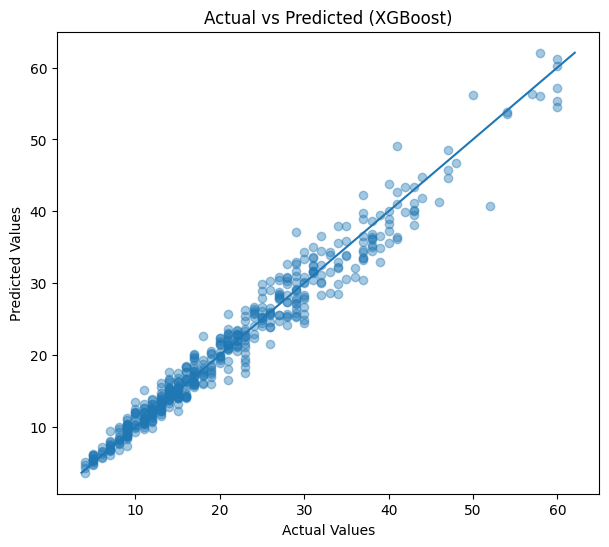

In [ ]:
#  Actual vs Predicted Scatter Plot

import matplotlib.pyplot as plt

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4)
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

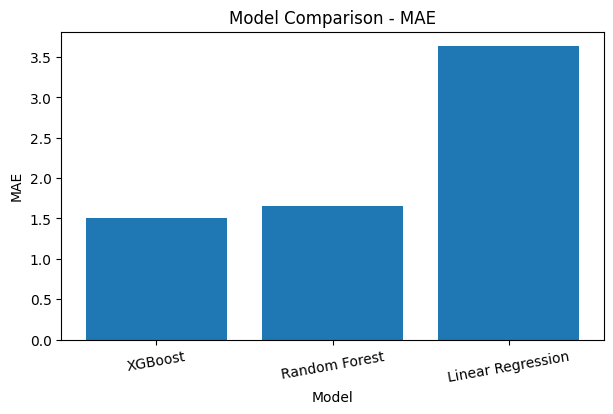

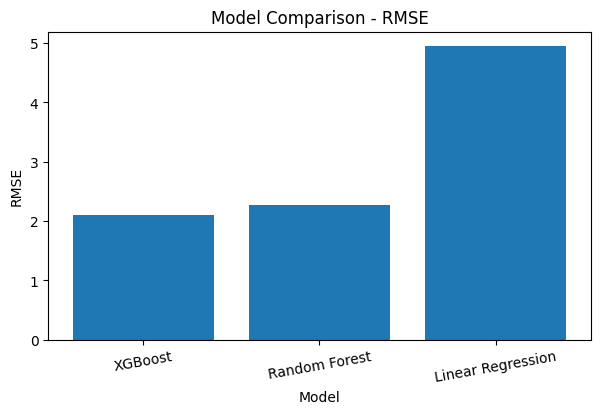

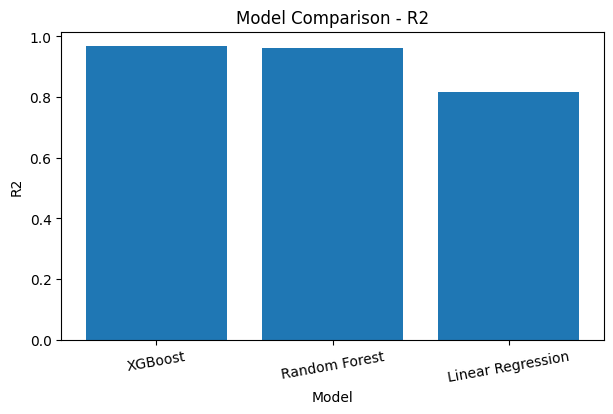

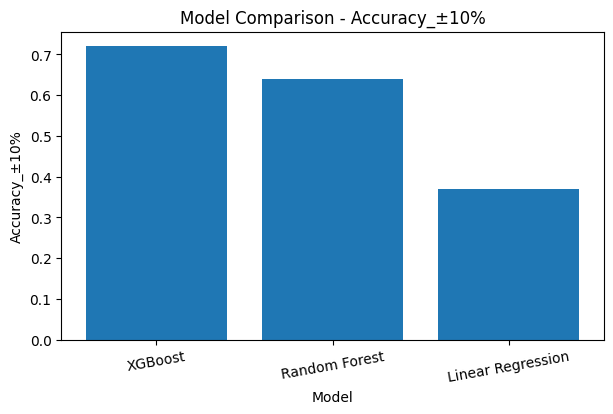

In [ ]:
#  Model Comparison Bar Charts

metrics = ["MAE", "RMSE", "R2", "Accuracy_±10%"]

for metric in metrics:
    plt.figure(figsize=(7, 4))
    plt.bar(results_df["Model"], results_df[metric])
    plt.title(f"Model Comparison - {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=10)
    plt.show()

In [ ]:
import joblib

joblib.dump(best_model, "roofing_pipeline.pkl")

['roofing_pipeline.pkl']

In [ ]:
import pandas as pd
import joblib

# Load saved model
model = joblib.load("roofing_pipeline.pkl")

new_input = {

    "roof_area_m2":200,
    "roof_height_m":1 ,
    "roof_type": "Lean-to",
    "roof_covering": "Asbestos Sheets",
    "labor_count": 10

}

# Convert to DataFrame
new_df = pd.DataFrame([new_input])

print("Input Data:")
display(new_df)

# Predict
predicted_duration = model.predict(new_df)

print("Predicted Duration_Days:", round(predicted_duration[0]))

Input Data:


,roof_area_m2,roof_height_m,roof_type,roof_covering,labor_count
0,200,1,Lean-to,Asbestos Sheets,10


Predicted Duration_Days: 11
